In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nba_api.stats.endpoints import leaguedashplayerstats

print("Everything is imported")



Everything is imported


In [74]:
!jupyter nbconvert --to notebook --inplace nba_salary_analysis.ipynb

[NbConvertApp] Converting notebook nba_salary_analysis.ipynb to notebook
[NbConvertApp] Writing 147002 bytes to nba_salary_analysis.ipynb


In [51]:
salary_data = {
    'PLAYER_NAME': [
        'Stephen Curry',
        'Nikola Jokic',
        'Kevin Durant',
        'Giannis Antetokounmpo',
        'LeBron James',
        'Luka Doncic',
        'Joel Embiid',
        'Jayson Tatum',
        'Anthony Davis',
        'Devin Booker',
        'Shai Gilgeous-Alexander',
        'Donovan Mitchell',
        'Jaylen Brown',
        'Trae Young',
        'Kyrie Irving',
        'Damian Lillard',
        'Jimmy Butler',
        'Tyrese Haliburton',
        'Karl-Anthony Towns',
        'Bam Adebayo',
        'Ja Morant',
        'Bradley Beal',
        'Paolo Banchero',
        'Zion Williamson',
        'Victor Wembanyama',
    ],


    

    'SALARY_MILLIONS': [
        55.8,
        51.4,
        51.2,
        48.8,
        48.7,
        43.0,
        47.6,
        34.8,
        43.2,
        49.2,
        35.9,
        35.4,
        49.7,
        43.0,
        41.0,
        48.8,
        48.8,
        42.2,
        49.2,
        34.8,
        36.7,
        50.2,
        12.2,
        36.7,
        12.8,  
    ]
}

salary_df = pd.DataFrame(salary_data)

print(len(salary_df))

salary_df.head()


25


,PLAYER_NAME,SALARY_MILLIONS
0,Stephen Curry,55.8
1,Nikola Jokic,51.4
2,Kevin Durant,51.2
3,Giannis Antetokounmpo,48.8
4,LeBron James,48.7


In [55]:
merge_df = pd.merge(
    salary_df,
    df,
    on='PLAYER_NAME',
)

print(len(merge_df))
merge_df.head()

25


,PLAYER_NAME,SALARY_MILLIONS,TEAM_ABBREVIATION,PTS,REB,AST
0,Stephen Curry,55.8,GSW,24.5,4.4,6.0
1,Nikola Jokić,51.4,DEN,29.6,12.7,10.2
2,Kevin Durant,51.2,PHX,26.6,6.0,4.2
3,Giannis Antetokounmpo,48.8,MIL,30.4,11.9,6.5
4,LeBron James,48.7,LAL,24.4,7.8,8.2


In [60]:
merge_df['PERFORMANCE_SCORE'] = (
    merge_df['PTS']
    + merge_df['REB']
    + merge_df['AST']
)
merge_df[['PLAYER_NAME',
           'PERFORMANCE_SCORE']].head()

,PLAYER_NAME,PERFORMANCE_SCORE
0,Stephen Curry,34.9
1,Nikola Jokić,52.5
2,Kevin Durant,36.8
3,Giannis Antetokounmpo,48.8
4,LeBron James,40.4


In [61]:
merge_df['VALUE_SCORE'] = (
    merge_df['PERFORMANCE_SCORE']
    / merge_df['SALARY_MILLIONS']
)

merge_df[['PLAYER_NAME',
           'VALUE_SCORE']].head()

,PLAYER_NAME,VALUE_SCORE
0,Stephen Curry,0.625448
1,Nikola Jokić,1.021401
2,Kevin Durant,0.718750
3,Giannis Antetokounmpo,1.000000
4,LeBron James,0.829569


In [62]:
best_value = merge_df.sort_values(
    by='VALUE_SCORE',
    ascending=False
)
best_value[['PLAYER_NAME',
            'SALARY_MILLIONS',
            'PERFORMANCE_SCORE',
            'VALUE_SCORE'
            ]].head(10)


,PLAYER_NAME,SALARY_MILLIONS,PERFORMANCE_SCORE,VALUE_SCORE
22,Paolo Banchero,12.2,38.2,3.131148
24,Victor Wembanyama,12.8,39.0,3.046875
10,Shai Gilgeous-Alexander,35.9,44.1,1.228412
7,Jayson Tatum,34.8,41.5,1.192529
5,Luka Dončić,43.0,44.1,1.025581
1,Nikola Jokić,51.4,52.5,1.021401
23,Zion Williamson,36.7,37.1,1.010899
3,Giannis Antetokounmpo,48.8,48.8,1.000000
11,Donovan Mitchell,35.4,33.5,0.946328
20,Ja Morant,36.7,34.6,0.942779


In [63]:
worst_value = merge_df.sort_values(
    by='VALUE_SCORE',
    ascending=True
)

worst_value[['PLAYER_NAME',
             'SALARY_MILLIONS',
             'PERFORMANCE_SCORE',
             'VALUE_SCORE'
             ]].head(10)

,PLAYER_NAME,SALARY_MILLIONS,PERFORMANCE_SCORE,VALUE_SCORE
21,Bradley Beal,50.2,24.0,0.478088
16,Jimmy Butler III,48.8,28.3,0.579918
0,Stephen Curry,55.8,34.9,0.625448
12,Jaylen Brown,49.7,32.5,0.653924
2,Kevin Durant,51.2,36.8,0.718750
17,Tyrese Haliburton,42.2,31.3,0.741706
9,Devin Booker,49.2,36.8,0.747967
15,Damian Lillard,48.8,36.7,0.752049
6,Joel Embiid,47.6,36.5,0.766807
18,Karl-Anthony Towns,49.2,40.3,0.819106


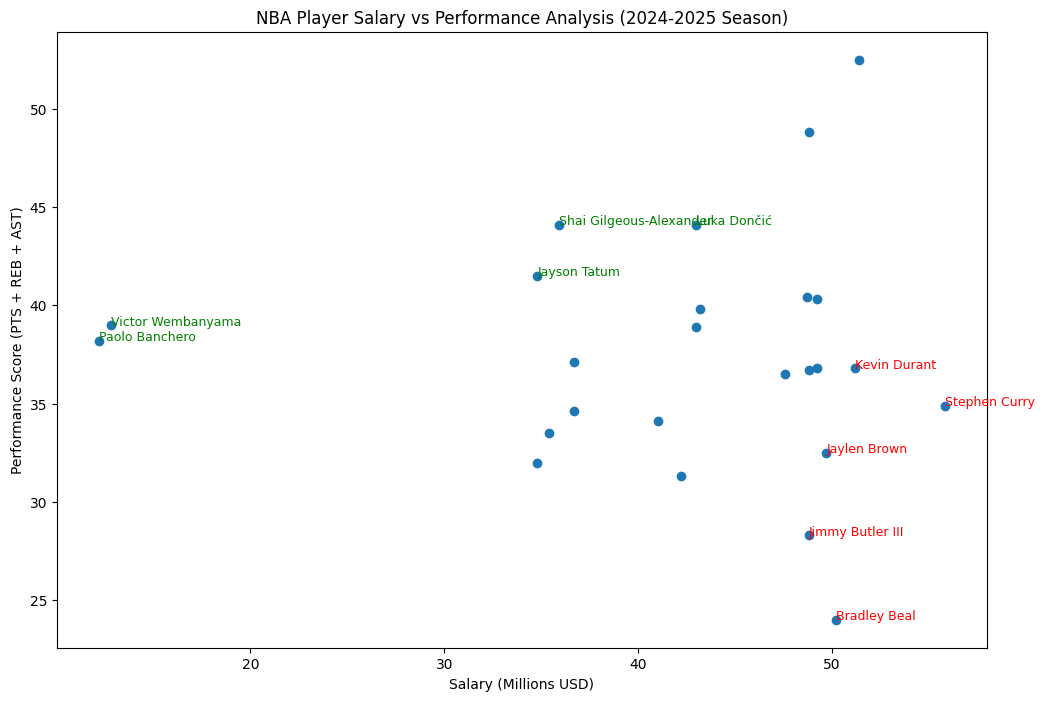

In [72]:
top5 = best_value.head(5)
bottom5 = worst_value.head(5)

plt.figure(figsize=(12, 8))

plt.scatter(
    merge_df['SALARY_MILLIONS'],
    merge_df['PERFORMANCE_SCORE']
)

for _, row in top5.iterrows():
    plt.annotate(
        row['PLAYER_NAME'],
        (row['SALARY_MILLIONS'], 
         row['PERFORMANCE_SCORE']),
        fontsize=9,
        color='green'
    )

for _, row in bottom5.iterrows():
    plt.annotate(
        row['PLAYER_NAME'],
        (row['SALARY_MILLIONS'], 
         row['PERFORMANCE_SCORE']),
        fontsize=9,
        color='red'
    )
plt.xlabel('Salary (Millions USD)')
plt.ylabel('Performance Score (PTS + REB + AST)')
plt.title('NBA Player Salary vs Performance Analysis (2024-2025 Season)')

plt.show()

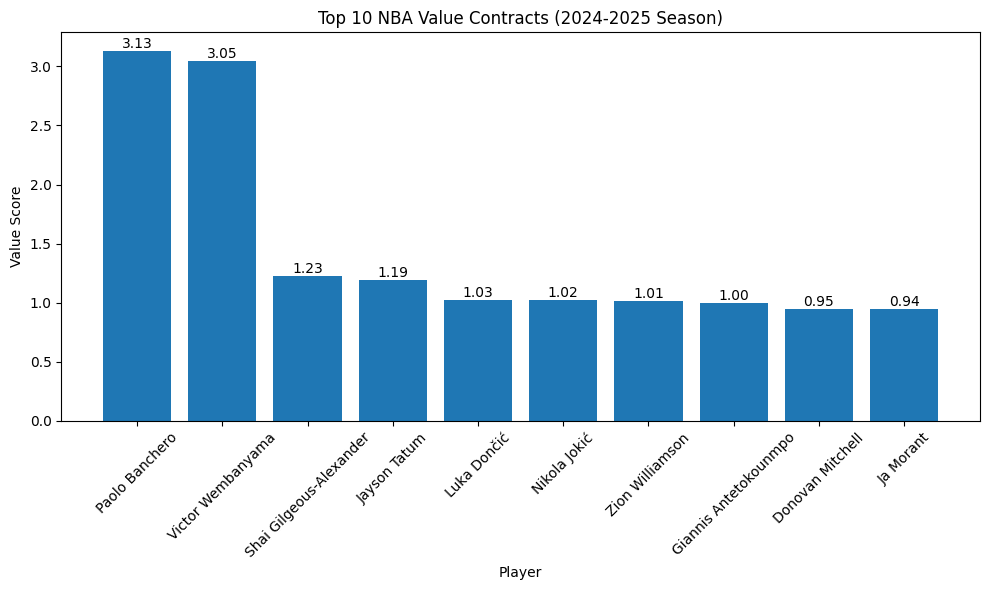

In [69]:
top10 = best_value.head(10)

plt.figure(figsize=(10, 6))

bars =plt.bar(
    top10['PLAYER_NAME'],
    top10['VALUE_SCORE'],)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)

plt.ylabel('Value Score')
plt.xlabel('Player')
plt.title('Top 10 NBA Value Contracts (2024-2025 Season)')
plt.tight_layout()

plt.show()

In [71]:
plt.savefig('NBA Player Salary vs Performance Analysis (2024-2025 Season).png')
plt.savefig('Top 10 NBA Value Contracts (2024-2025 Season).png')

<Figure size 640x480 with 0 Axes>

In [37]:
stats = leaguedashplayerstats.LeagueDashPlayerStats(
    season='2024-25',
    per_mode_detailed='PerGame'
)
df = stats.get_data_frames()[0]
df.head()

df =df[['PLAYER_NAME',
       'TEAM_ABBREVIATION',
       'PTS',
       'REB',
       'AST']]

df.head()

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST
0,A.J. Lawson,TOR,9.1,3.3,1.2
1,AJ Green,MIL,7.4,2.4,1.5
2,AJ Johnson,WAS,7.6,2.0,2.6
3,Aaron Gordon,DEN,14.7,4.8,3.2
4,Aaron Holiday,HOU,5.5,1.3,1.3
